# 7. Backpropagation Algorithm
---
Backpropagation is the algorithm that computes **gradients of the loss with respect to every weight in the network**. It's just the chain rule, applied efficiently using dynamic programming.


## 7.1 The Big Picture

Training a neural network involves 4 steps, repeated many times:

```
1. FORWARD PASS   → compute predictions ŷ and loss L
2. BACKWARD PASS  → compute ∂L/∂W for every weight (backprop)
3. UPDATE WEIGHTS → W = W - lr × ∂L/∂W  (gradient descent)
4. REPEAT
```

Backprop tells us: **"nudge this weight up or down by how much to reduce the loss?"**


In [8]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

def sigmoid(z): 
    return 1 / (1 + np.exp(-z))
def sigmoid_prime(z): s = sigmoid(z); return s * (1 - s)
def relu(z): 
    return np.maximum(0, z)
def relu_prime(z): 
    return (z > 0).astype(float)

# Small network: 2 inputs → 3 hidden (sigmoid) → 1 output (sigmoid)
# Using sigmoid throughout for clean math derivation

def init_params(layer_dims, seed=42):
    np.random.seed(seed)
    params = {}
    for l in range(1, len(layer_dims)):
        params[f'W{l}'] = np.random.randn(layer_dims[l], layer_dims[l-1]) * 0.5
        params[f'b{l}'] = np.zeros((layer_dims[l], 1))
    return params

layer_dims = [2, 3, 1]
params = init_params(layer_dims)
print("Network: 2 → 3 → 1 (sigmoid throughout)")
print(f"W1:\n{np.round(params['W1'],3)}")
print(f"b1: {params['b1'].flatten()}")
print(f"W2: {np.round(params['W2'],3)}")
print(f"b2: {params['b2'].flatten()}")

Network: 2 → 3 → 1 (sigmoid throughout)
W1:
[[ 0.248 -0.069]
 [ 0.324  0.762]
 [-0.117 -0.117]]
b1: [0. 0. 0.]
W2: [[ 0.79   0.384 -0.235]]
b2: [0.]


In [2]:
# ── Step 1: Forward Pass ──
def forward(X, params):
    W1, b1 = params['W1'], params['b1']
    W2, b2 = params['W2'], params['b2']

    z1 = W1 @ X + b1
    a1 = sigmoid(z1)

    z2 = W2 @ a1 + b2
    a2 = sigmoid(z2)

    cache = {'X': X, 'z1': z1, 'a1': a1, 'z2': z2, 'a2': a2}
    return a2, cache

# XOR-like dataset
X = np.array([[0, 0, 1, 1],
              [0, 1, 0, 1]])    # shape (2, 4)
y = np.array([[0, 1, 1, 0]])   # XOR labels, shape (1, 4)

y_hat, cache = forward(X, params)
loss = -np.mean(y * np.log(y_hat + 1e-8) + (1-y) * np.log(1-y_hat + 1e-8))

print("=== Forward Pass ===")
print(f"Predictions: {np.round(y_hat, 3)}")
print(f"True labels: {y}")
print(f"Loss (BCE):  {loss:.4f}")

=== Forward Pass ===
Predictions: [[0.615 0.63  0.635 0.649]]
True labels: [[0 1 1 0]]
Loss (BCE):  0.7291


In [3]:
# ── Step 2: Backward Pass (Backprop) ──
def backward(y, cache, params):
    m = y.shape[1]  # number of samples
    X, z1, a1, z2, a2 = cache['X'], cache['z1'], cache['a1'], cache['z2'], cache['a2']
    W1, W2 = params['W1'], params['W2']

    # Output layer gradients
    dL_da2 = -(y / (a2 + 1e-8) - (1-y) / (1-a2 + 1e-8))  # ∂L/∂a2
    da2_dz2 = sigmoid_prime(z2)                              # ∂a2/∂z2
    dL_dz2 = dL_da2 * da2_dz2                               # chain rule: ∂L/∂z2

    # Weight gradients for layer 2
    dL_dW2 = (dL_dz2 @ a1.T) / m   # ∂L/∂W2
    dL_db2 = np.mean(dL_dz2, axis=1, keepdims=True)

    # Hidden layer gradients (backprop through W2)
    dL_da1 = W2.T @ dL_dz2         # ∂L/∂a1
    da1_dz1 = sigmoid_prime(z1)    # ∂a1/∂z1
    dL_dz1 = dL_da1 * da1_dz1      # chain rule: ∂L/∂z1

    # Weight gradients for layer 1
    dL_dW1 = (dL_dz1 @ X.T) / m
    dL_db1 = np.mean(dL_dz1, axis=1, keepdims=True)

    grads = {'W1': dL_dW1, 'b1': dL_db1, 'W2': dL_dW2, 'b2': dL_db2}
    return grads

grads = backward(y, cache, params)
print("=== Gradients (∂L/∂W) ===")
print(f"∂L/∂W2: {np.round(grads['W2'], 4)}")
print(f"∂L/∂b2: {np.round(grads['b2'].flatten(), 4)}")
print(f"\n∂L/∂W1:\n{np.round(grads['W1'], 4)}")


=== Gradients (∂L/∂W) ===
∂L/∂W2: [[0.0694 0.0822 0.0621]]
∂L/∂b2: [0.1323]

∂L/∂W1:
[[ 0.014   0.0135]
 [ 0.0032  0.004 ]
 [-0.0041 -0.004 ]]


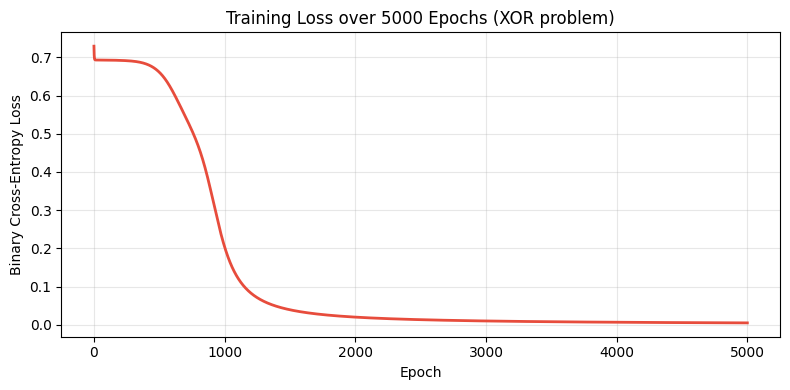


Final predictions: [[0.006 0.996 0.996 0.005]]
True labels:       [[0 1 1 0]]
Accuracy: 100%


In [4]:
# ── Step 3: Update Weights (Gradient Descent) ──
def update_params(params, grads, learning_rate=0.5):
    for key in params:
        params[key] = params[key] - learning_rate * grads[key]
    return params

# ── Step 4: Training Loop ──
params = init_params(layer_dims)  # reset

losses = []
for epoch in range(5000):
    y_hat, cache = forward(X, params)
    loss = -np.mean(y * np.log(y_hat + 1e-8) + (1-y) * np.log(1-y_hat + 1e-8))
    grads = backward(y, cache, params)
    params = update_params(params, grads, learning_rate=0.5)
    losses.append(loss)

# Plot training loss
plt.figure(figsize=(8, 4))
plt.plot(losses, color='#E74C3C', lw=2)
plt.title("Training Loss over 5000 Epochs (XOR problem)", fontsize=12)
plt.xlabel("Epoch"); plt.ylabel("Binary Cross-Entropy Loss")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

y_hat_final, _ = forward(X, params)
print(f"\nFinal predictions: {np.round(y_hat_final, 3)}")
print(f"True labels:       {y}")
print(f"Accuracy: {np.mean((y_hat_final > 0.5) == y):.0%}")

## 7.2 Gradient Check

A powerful debugging tool: verify your backprop gradients numerically.

For each weight $w_i$: $\frac{\partial L}{\partial w_i} \approx \frac{L(w_i + \epsilon) - L(w_i - \epsilon)}{2\epsilon}$


In [5]:
def compute_loss(params, X, y):
    y_hat, _ = forward(X, params)
    return -np.mean(y * np.log(y_hat + 1e-8) + (1-y) * np.log(1-y_hat + 1e-8))

def gradient_check(params, grads, X, y, eps=1e-5):
    print("Gradient Check (analytical vs numerical):")
    for key in ['W1', 'b1', 'W2', 'b2']:
        param = params[key]
        grad_analytical = grads[key]
        grad_numerical  = np.zeros_like(param)

        for idx in np.ndindex(param.shape):
            p_plus  = {k: v.copy() for k, v in params.items()}
            p_minus = {k: v.copy() for k, v in params.items()}
            p_plus[key][idx]  += eps
            p_minus[key][idx] -= eps
            grad_numerical[idx] = (compute_loss(p_plus, X, y) - compute_loss(p_minus, X, y)) / (2*eps)

        diff = np.max(np.abs(grad_analytical - grad_numerical))
        status = "✓ PASS" if diff < 1e-5 else "❌ FAIL"
        print(f"  {key}: max diff = {diff:.2e}  {status}")

# Use fresh params for cleaner check
params_check = init_params([2, 3, 1], seed=7)
y_hat_c, cache_c = forward(X, params_check)
grads_c = backward(y, cache_c, params_check)

gradient_check(params_check, grads_c, X, y)


Gradient Check (analytical vs numerical):
  W1: max diff = 3.52e-12  ✓ PASS
  b1: max diff = 1.21e-12  ✓ PASS
  W2: max diff = 1.97e-12  ✓ PASS
  b2: max diff = 7.32e-12  ✓ PASS


## ✏️ Exercises

1. **Code:** Change the learning rate from 0.5 to 5.0 and 0.01. What happens to training? Plot all three loss curves on the same axes.
2. **Trace by hand:** For the 2→3→1 network, write out the full chain rule expression for $\partial L / \partial W1_{11}$ (weight connecting input 1 to hidden neuron 1).
3. **Code:** Extend the training loop to also compute and store **accuracy** at each epoch. Plot loss and accuracy side by side.


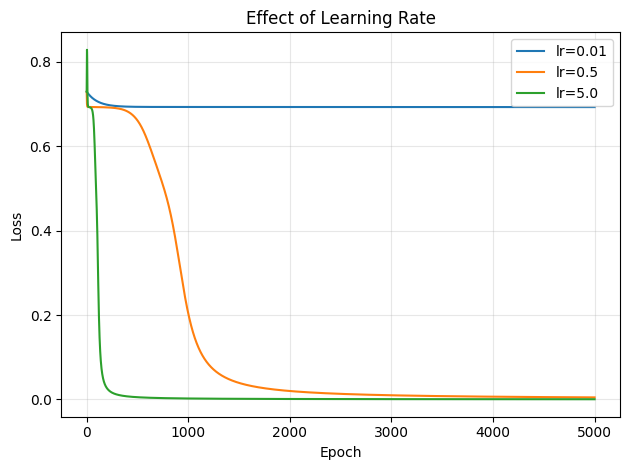

In [6]:
# Exercise 1 starter — compare learning rates
for lr in [0.01, 0.5, 5.0]:
    params_lr = init_params(layer_dims)
    losses_lr = []
    for epoch in range(5000):
        y_hat_lr, cache_lr = forward(X, params_lr)
        loss_lr = -np.mean(y * np.log(y_hat_lr + 1e-8) + (1-y) * np.log(1-y_hat_lr + 1e-8))
        grads_lr = backward(y, cache_lr, params_lr)
        params_lr = update_params(params_lr, grads_lr, learning_rate=lr)
        losses_lr.append(loss_lr)
    plt.plot(losses_lr, label=f'lr={lr}')

plt.legend(); plt.title("Effect of Learning Rate"); plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
